# 1. IMAGE SEGMENTATION

## 1.1 THRESHOLD-BASED SEGMENTATION

El objetivo de esta sección es detectar defectos en una radiografía de una soldadura. Sabemos que los defectos dejan pasar más los rayos X, por lo que se ven como las regiones más brillantes del interior.
Para lograr aislar estos defectos, aplicaremos una técnica llamada Umbralización (Thresholding).

La regla matemática básica es:

- Si el valor del píxel $f(x,y) > T$ (siendo $T$ nuestro umbral), el nuevo píxel será Blanco (1 o 255).
- Si el valor del píxel $f(x,y) \le T$, el nuevo píxel será Negro (0).

¿Cómo elegimos $T$?

Umbral de Otsu: El laboratorio nos pide usar primero la función threshold_otsu. Este es un algoritmo que analiza el histograma de la imagen (la distribución de grises) y calcula automáticamente el valor $T$ óptimo que separa la imagen en dos clases equilibradas (fondo y objeto), minimizando la varianza estadística dentro de cada clase.

Umbral Manual: Otsu funciona muy bien cuando hay dos montañas claras (bimodal) en el histograma. Sin embargo, en una radiografía, los defectos brillantes son muy pequeños en área comparados con el resto de la soldadura. Esto engaña a Otsu. Por eso, el laboratorio nos pide luego ver el histograma para elegir a ojo un $T$ más alto que realmente aísle la "cola" brillante derecha del gráfico.

Filtro Gaussiano: Las imágenes médicas suelen tener ruido granulado. Si aplicamos el umbral directamente, obtendremos muchos "puntos" blancos falsos. Aplicaremos un filtro paso bajo Gaussiano, que funciona difuminando la imagen (promediando cada píxel con sus vecinos en forma de campana) para homogeneizar las manchas antes de aplicar el umbral.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, exposure
from skimage.morphology import rectangle, diamond, binary_opening, binary_dilation
from sklearn.cluster import KMeans
from scipy.ndimage import uniform_filter, generic_filter

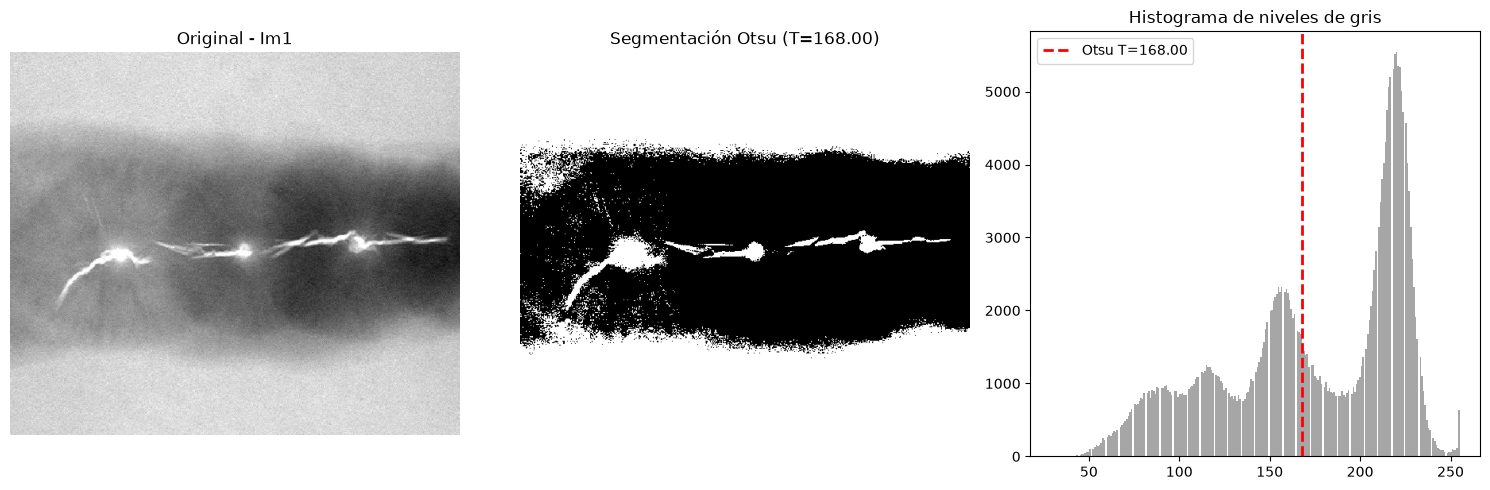

In [3]:
# 1. Leer la imagen y asegurarnos de que esté en escala de grises
img1 = io.imread('Im1.jpg', as_gray=True)

# 2. Calcular el umbral de Otsu y aplicar la máscara binaria
t_otsu = filters.threshold_otsu(img1)
mask_otsu = img1 > t_otsu

# 3. Visualizar la imagen original, la máscara de Otsu y el histograma
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mostrar imagen original
axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Original - Im1')
axes[0].axis('off')

# Mostrar segmentación de Otsu
axes[1].imshow(mask_otsu, cmap='gray')
axes[1].set_title(f'Segmentación Otsu (T={t_otsu:.2f})')
axes[1].axis('off')

# Mostrar el histograma
# img1.ravel() aplana la matriz 2D a 1D para calcular el histograma
axes[2].hist(img1.ravel(), bins=256, color='gray', alpha=0.7)
axes[2].axvline(t_otsu, color='r', linestyle='dashed', linewidth=2, label=f'Otsu T={t_otsu:.2f}')
axes[2].set_title('Histograma de niveles de gris')
axes[2].legend()

plt.tight_layout()
plt.show()

El programa detectó que un buen umbral seria en 168, otsu penso que habia que separar el fondo de la estructura, pero en realidad no buscamos eso. Un mejor umbral, teniendo en cuenta que queremos aislar solo los destellos mas brillantes, sería tomar solo lo ultimo del pico mas alto, cerca de 240. 

El filtro Gaussiano es un filtro "paso bajo". Las radiografías tienen un ruido granulado molesto (ruido de alta frecuencia). Si hacemos un zoom, veríamos puntitos blancos falsos Este filtro aplica una campana de Gauss sobre cada píxel. Básicamente, reemplaza el valor de cada píxel por un promedio ponderado de sus píxeles vecinos (los vecinos más cercanos importan más, los lejanos menos). Esto "difumina" la imagen suavemente, matando los puntitos de ruido rebeldes y unificando las manchas de los defectos reales.

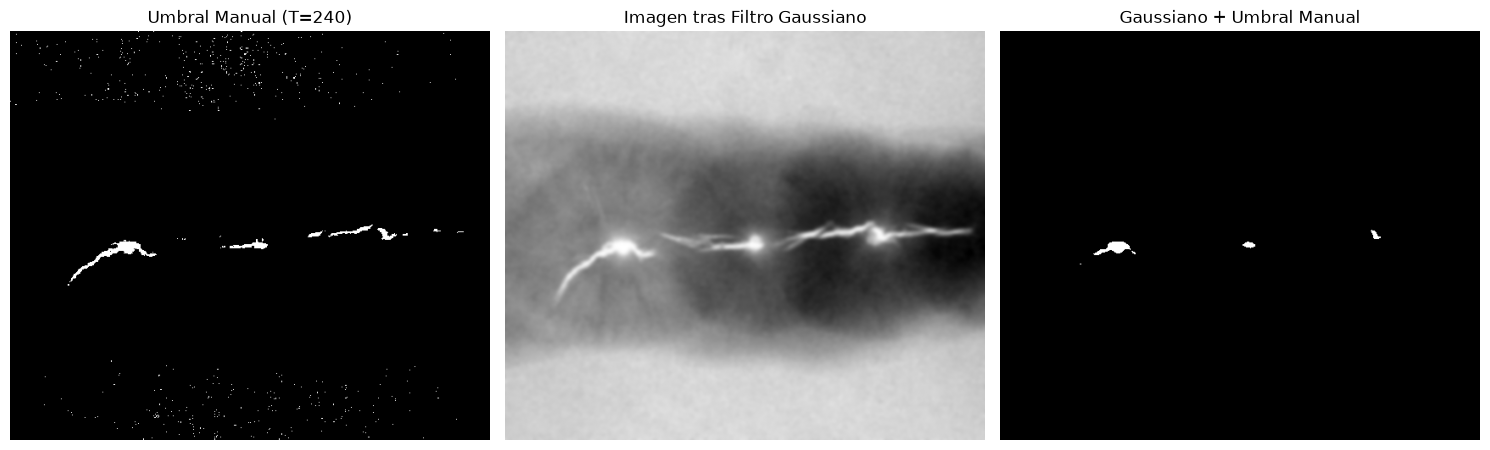

In [4]:
# --- 1. UMBRAL MANUAL ---
# Elegimos 240 para ignorar el fondo (pico de 220) y capturar solo el blanco brillante
t_manual = 240
mask_manual = img1 > t_manual

# --- 2. FILTRO GAUSSIANO + UMBRAL ---
# Aplicamos el filtro gaussiano. "sigma" controla el tamaño de la campana (qué tan borroso se hace).
img1_gaussian = filters.gaussian(img1, sigma=2)

# OJO: filters.gaussian convierte internamente la imagen a valores decimales entre 0.0 y 1.0
# Por lo tanto, nuestro umbral de 240 (escala de 255) debemos convertirlo a esa nueva escala matemática:
# T_nuevo = 240 / 255 = 0.941
t_gauss = 240 / 255.0
mask_gaussian = img1_gaussian > t_gauss

# --- 3. VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Umbral Manual sin filtro
axes[0].imshow(mask_manual, cmap='gray')
axes[0].set_title(f'Umbral Manual (T={t_manual})')
axes[0].axis('off')

# Imagen difuminada con el filtro Gaussiano (solo para que veas qué hace el filtro)
axes[1].imshow(img1_gaussian, cmap='gray')
axes[1].set_title('Imagen tras Filtro Gaussiano')
axes[1].axis('off')

# Umbral Manual sobre la imagen con filtro Gaussiano
axes[2].imshow(mask_gaussian, cmap='gray')
axes[2].set_title('Gaussiano + Umbral Manual')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 1.2 GRAYLEVEL IMAGE CLUSTERING-BASED SEGMENTATION

**¿Qué es K-Means?**
Es un algoritmo de aprendizaje no supervisado. Toma todos los valores de intensidad de los píxeles (que van de 0 a 1 o de 0 a 255) y busca agruparlos alrededor de $K$ centros o centroides. Si indicamos $K=3$, el algoritmo buscará 3 niveles de gris representativos que dividan mejor toda la imagen en 3 categorías.

**Formato de datos para scikit-learn:**
Una imagen es una matriz 2D (alto $\times$ ancho, ej. $300 \times 300$). KMeans no entiende matrices 2D; necesita una lista vertical de datos de dimensión $(N, 1)$, donde $N$ es el número total de píxeles ($300 \times 300 = 90000$). Por eso usaremos reshape(-1, 1) antes de entrenar el modelo.

**Análisis de Im2.jpg (3 centroides):**
Agruparemos Im2.jpg en $K=3$ clases. Gráficamente, veremos el histograma junto con las posiciones de los 3 centroides encontrados.   Análisis de Im3.jpg (Anillo vs. Centro Denso vs. Fondo):

Im3.jpg es la imagen de una galaxia o nebulosa. Nos piden identificar 3 regiones:   

- El fondo oscuro.

- El "anillo" exterior de materia menos densa.

- La región central muy densa y brillante.

**Uso de Filtros de Medios y Varianza Local:**
A veces, agrupar píxel por píxel genera ruido. Para mejorarlo, la guía nos pide calcular:

- Media local (uniform_filter): Promedia una vecindad alrededor de cada píxel. Esto suaviza las variaciones bruscas de intensidad.   
- Varianza local (generic_filter con np.var): Mide qué tanto cambian los píxeles alrededor de una región. Las zonas de transición o con textura tendrán una varianza alta, mientras que las zonas uniformes tendrán una varianza baja. Al combinar la Media y la Varianza, cada píxel pasa de tener 1 característica (su brillo) a tener 2 características [Media_local, Varianza_local] para entrenar el K-Means en un espacio 2D.

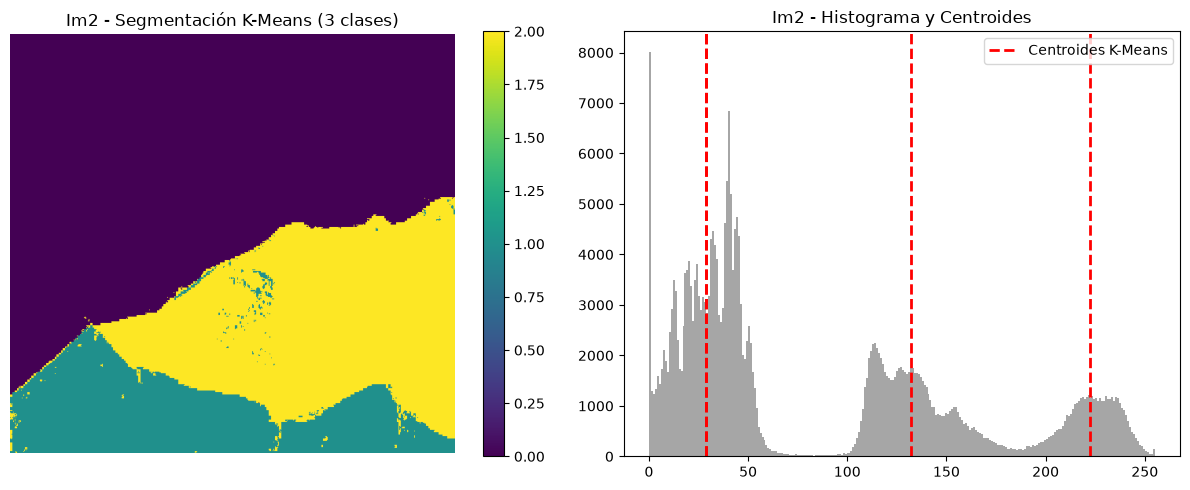

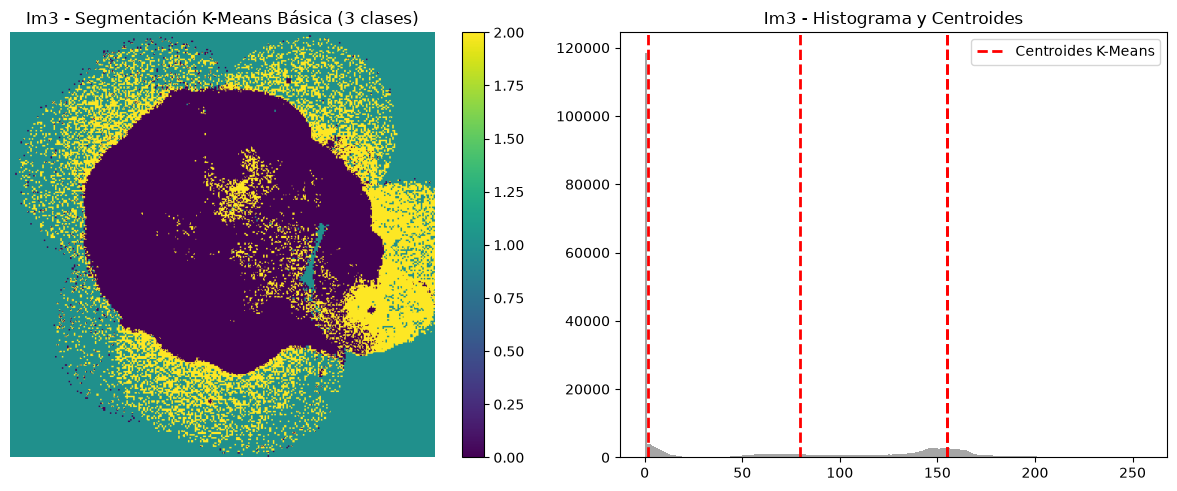

In [5]:
# --- PARTE A: Im2.jpg con K-Means (K=3) ---
img2 = io.imread('Im2.jpg', as_gray=True)

# Reorganizar la imagen de 2D a una columna 1D (N_pixeles, 1)
X2 = img2.reshape(-1, 1)

# Entrenar K-Means con 3 centroides
kmeans2 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X2)

# Obtener las etiquetas de cada píxel y reestructurar a la forma 2D original
segmented2 = kmeans2.labels_.reshape(img2.shape)
centroids2 = kmeans2.cluster_centers_

# Visualización de Im2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagen segmentada en pseudocolor
im2_plot = axes[0].imshow(segmented2, cmap='viridis')
axes[0].set_title('Im2 - Segmentación K-Means (3 clases)')
axes[0].axis('off')
plt.colorbar(im2_plot, ax=axes[0])

# Histograma con centroides
axes[1].hist(img2.ravel(), bins=256, color='gray', alpha=0.7)
for c in centroids2:
    axes[1].axvline(c[0], color='r', linestyle='--', linewidth=2)
axes[1].axvline(centroids2[0][0], color='r', linestyle='--', linewidth=2, label='Centroides K-Means')
axes[1].set_title('Im2 - Histograma y Centroides')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- PARTE B: Im3.jpg con K-Means básico (K=3) ---
img3 = io.imread('Im3.jpg', as_gray=True)

X3 = img3.reshape(-1, 1)
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X3)
segmented3 = kmeans3.labels_.reshape(img3.shape)
centroids3 = kmeans3.cluster_centers_

# Visualización de Im3 básica
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagen segmentada
im3_plot = axes[0].imshow(segmented3, cmap='viridis')
axes[0].set_title('Im3 - Segmentación K-Means Básica (3 clases)')
axes[0].axis('off')
plt.colorbar(im3_plot, ax=axes[0])

# Histograma con centroides
axes[1].hist(img3.ravel(), bins=256, color='gray', alpha=0.7)
for c in centroids3:
    axes[1].axvline(c[0], color='r', linestyle='--', linewidth=2)
axes[1].axvline(centroids3[0][0], color='r', linestyle='--', linewidth=2, label='Centroides K-Means')
axes[1].set_title('Im3 - Histograma y Centroides')
axes[1].legend()

plt.tight_layout()
plt.show()

1. Análisis de Im2.jpg (Montañas y Cielo)

En el Histograma (derecha): El histograma tiene 3 montañas principales, una gran montaña entre $0$ y $60$ (tonos oscuros), otra montaña alrededor de $120$-$150$ (tonos medios) y una montaña final entre $210$ y $250$ (tonos muy claros/blancos).
El algoritmo colocó automáticamente las 3 líneas rojas punteadas (los centroides) justo en el centro de masa de cada una de esas tres montañas (aproximadamente en $30$, $133$ y $222$). 

En la Imagen (izquierda): Cada píxel de la foto fue asignado a la línea roja más cercana. Clase 0 (Morado) captura la zona más oscura (el cielo o fondo superior), clase 1 (Verde/Azul) Captura los tonos medios de la montaña inferior y clase 2 (Amarillo) Captura las partes iluminadas y brillantes de las montañas.

2. Análisis de Im3.jpg (La Nebulosa/Célula)

En el Histograma (derecha): Aquí hay una barra gigante en $0$ (el fondo negro ocupando la mayor parte de la imagen) y luego datos muy extendidos entre $50$ y $170$. 

En la Imagen (izquierda): Si miras el resultado, verás que la imagen se siente con mucho ruido tipo "sal y pimienta" (puntos sueltos verdes y amarillos mezclados de forma rugosa). Esto pasa porque K-Means clasifica píxel por píxel independientemente, basándose únicamente en su brillo individual. Si dos píxeles vecinos difieren un poco en brillo debido al ruido, terminan en clases distintas.

El ejercicio nos pide solucionar esa "rugosidad" en Im3.jpg usando información espacial local:   

- Media Local (uniform_filter): En lugar de mirar el píxel solo, calculamos el promedio de sus vecinos en una ventana (por ejemplo, $9 \times 9$). Esto elimina el ruido y suaviza la segmentación del "anillo".   

- Varianza Local (generic_filter con np.var): La varianza mide el contraste o textura local. Zonas lisas tienen varianza baja; zonas rugosas/bordes tienen varianza alta.   Clustering en 2D: Combinaremos la media local y la varianza para darle a K-Means 2 dimensiones de datos por cada píxel [Media, Varianza] en lugar de 1 sola.   

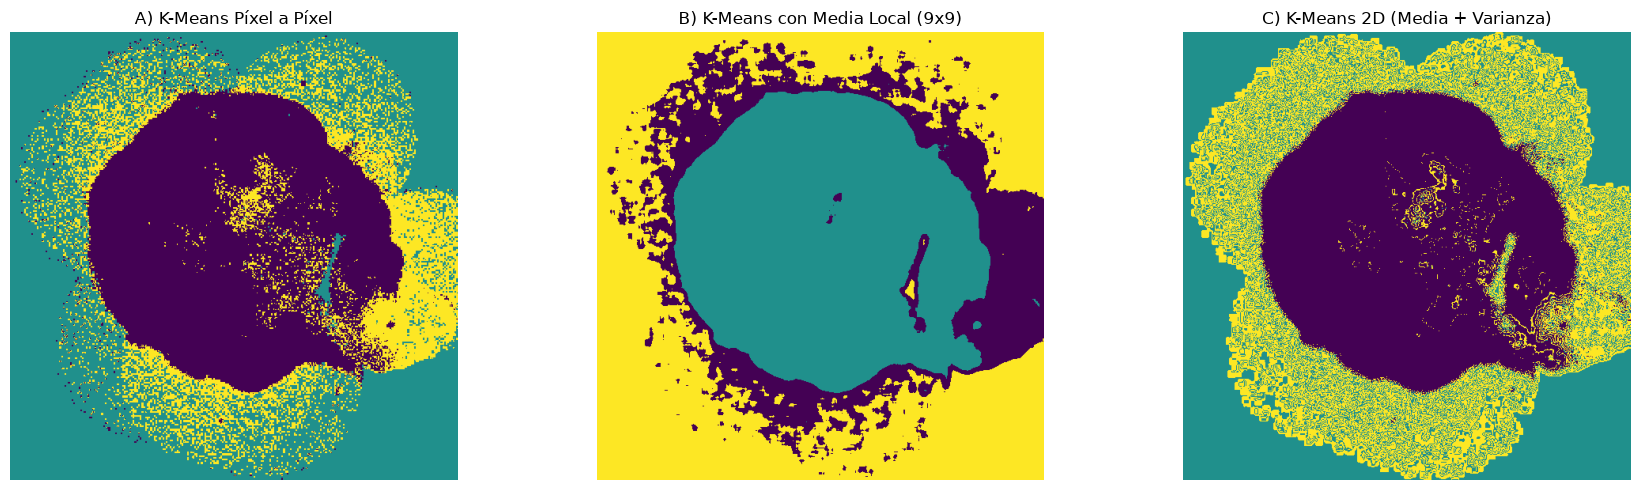

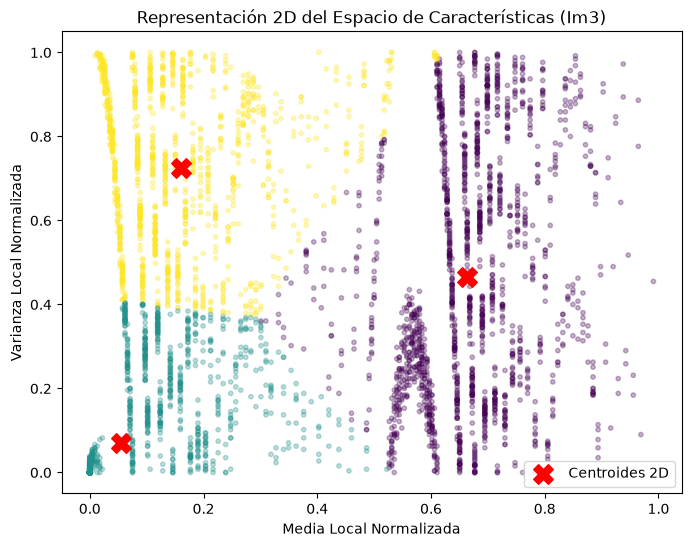

In [7]:
# --- 1. MEDIA LOCAL ---
# Calculamos el promedio en ventanas de 9x9 alrededor de cada píxel
img3_mean = uniform_filter(img3, size=9)

# K-Means usando solo la media local
X3_mean = img3_mean.reshape(-1, 1)
kmeans3_mean = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X3_mean)
segmented3_mean = kmeans3_mean.labels_.reshape(img3.shape)

# --- 2. VARIANZA LOCAL + MEDIA (2D) ---
# Para no tardar demasiado, podemos calcular la varianza como: Var(X) = E[X^2] - (E[X])^2
# usando el filtro uniforme, que es matemáticamente idéntico y extremadamente rápido
img3_mean_sq = uniform_filter(img3**2, size=9)
img3_var = img3_mean_sq - (img3_mean**2)

# Normalizamos ambas características para que tengan una escala similar
mean_norm = (img3_mean - img3_mean.min()) / (img3_mean.max() - img3_mean.min())
var_norm = (img3_var - img3_var.min()) / (img3_var.max() - img3_var.min())

# Combinar en una matriz de 2 columnas: [Media, Varianza]
X3_2d = np.column_stack((mean_norm.ravel(), var_norm.ravel()))

# K-Means en 2D
kmeans3_2d = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X3_2d)
segmented3_2d = kmeans3_2d.labels_.reshape(img3.shape)

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original segmentación básica
axes[0].imshow(segmented3, cmap='viridis')
axes[0].set_title('A) K-Means Píxel a Píxel')
axes[0].axis('off')

# Segmentación con Media Local
axes[1].imshow(segmented3_mean, cmap='viridis')
axes[1].set_title('B) K-Means con Media Local (9x9)')
axes[1].axis('off')

# Segmentación 2D (Media + Varianza)
axes[2].imshow(segmented3_2d, cmap='viridis')
axes[2].set_title('C) K-Means 2D (Media + Varianza)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# --- GRÁFICO 2D DE DATOS Y CENTROIDES ---
plt.figure(figsize=(8, 6))
# Muestreamos 5000 puntos al azar para no saturar el gráfico 2D
indices = np.random.choice(X3_2d.shape[0], size=5000, replace=False)
plt.scatter(X3_2d[indices, 0], X3_2d[indices, 1], c=kmeans3_2d.labels_[indices], cmap='viridis', alpha=0.3, s=10)
# Trazar los centroides 2D
plt.scatter(kmeans3_2d.cluster_centers_[:, 0], kmeans3_2d.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroides 2D')
plt.xlabel('Media Local Normalizada')
plt.ylabel('Varianza Local Normalizada')
plt.title('Representación 2D del Espacio de Características (Im3)')
plt.legend()
plt.show()

## 1.3 GRAYLEVEL IMAGE CLUSTERING-BASED SEGMENTATION

En este ejercicio aplicaremos K-Means a una imagen RGB (peppers.png) para agrupar sus píxeles según similitud de color en 5 clusters (rojos, verdes, amarillos, blancos y fondo).   

Espacio de Características 3D:
A diferencia de las imágenes en escala de grises (que tienen 1 canal) o de la matriz 2D de media/varianza, una imagen a color tiene 3 canales: Red, Green y Blue (RGB).
Cada píxel $(x,y)$ se convierte en un punto tridimensional: $(R, G, B)$.   

Reestructuración de la matriz:
La imagen tiene forma (Alto, Ancho, 3). Para entregársela a sklearn.cluster.KMeans, debemos "aplanar" las dimensiones espaciales a (Alto * Ancho, 3).   

Reconstrucción con los centroides:
Tras entrenar K-Means con $K=5$, cada centroide calculado representará un color promedio de cada uno de los 5 grupos. Para reconstruir la imagen segmentada, reemplazamos la etiqueta de cada píxel por el valor RGB exacto del centroide de su clase.   

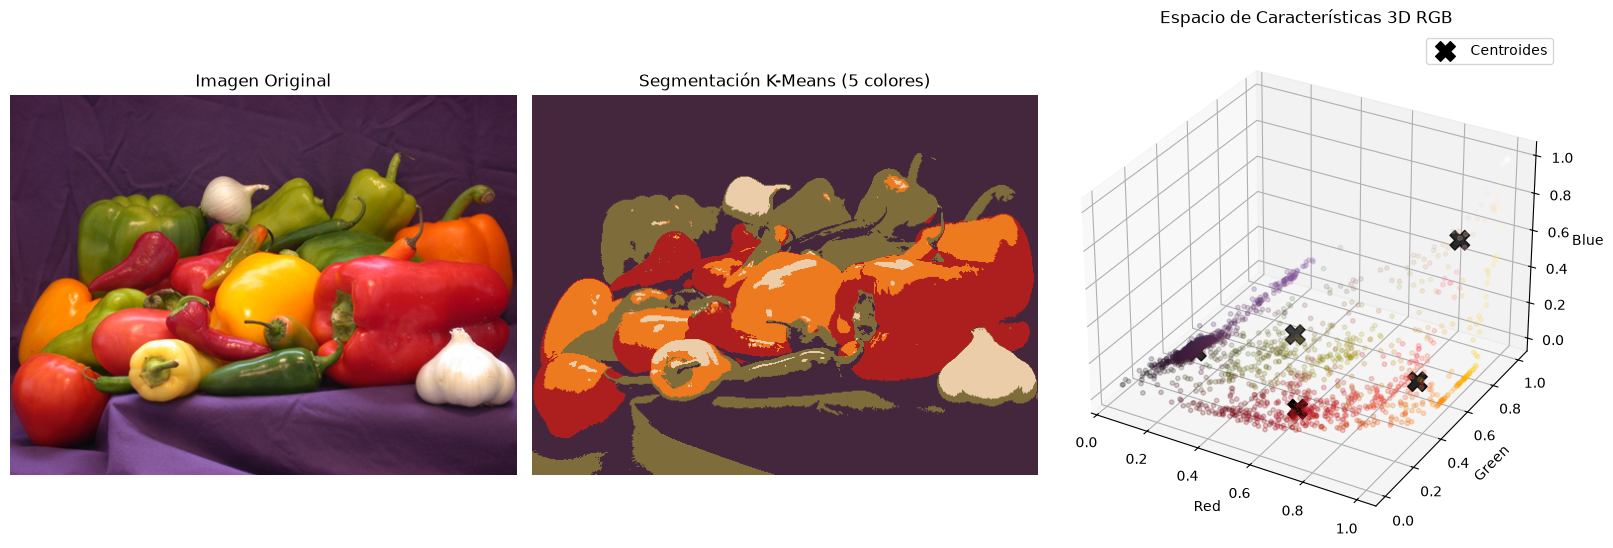

In [8]:
# --- 1. LEER LA IMAGEN A COLOR ---
img_peppers = io.imread('peppers.png')

# Si la imagen tiene canal alfa (PNG de 4 canales RGBA), nos quedamos solo con los primeros 3 (RGB)
if img_peppers.shape[2] == 4:
    img_peppers = img_peppers[:, :, :3]

# Normalizamos los datos a rango [0, 1] si están en uint8 [0, 255]
if img_peppers.dtype == np.uint8:
    img_peppers_norm = img_peppers / 255.0
else:
    img_peppers_norm = img_peppers.copy()

# --- 2. PREPARAR DATOS PARA K-MEANS (N_pixeles, 3) ---
h, w, c = img_peppers_norm.shape
X_peppers = img_peppers_norm.reshape(-1, 3)

# --- 3. ENTRENAR K-MEANS CON K=5 CLUSTERS ---
kmeans_peppers = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_peppers)

# --- 4. RECONSTRUIR LA IMAGEN SEGMENTADA ---
# Reemplazamos cada etiqueta por el valor RGB de su centroide
segmented_pixels = kmeans_peppers.cluster_centers_[kmeans_peppers.labels_]
segmented_peppers = segmented_pixels.reshape(h, w, c)

# --- 5. VISUALIZACIÓN SIDE-BY-SIDE E EN ESPACIO 3D ---
fig = plt.figure(figsize=(16, 6))

# Original vs Segmentada
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(img_peppers)
ax1.set_title('Imagen Original')
ax1.axis('off')

ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(segmented_peppers)
ax2.set_title('Segmentación K-Means (5 colores)')
ax2.axis('off')

# Espacio 3D RGB
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# Muestreamos 2000 puntos para graficar sin lentitud
indices = np.random.choice(X_peppers.shape[0], size=2000, replace=False)
sample_pixels = X_peppers[indices]

# Graficar los puntos usando su propio color RGB real
ax3.scatter(sample_pixels[:, 0], sample_pixels[:, 1], sample_pixels[:, 2], 
            c=sample_pixels, s=10, alpha=0.5)

# Graficar los 5 centroides
centroids_rgb = kmeans_peppers.cluster_centers_
ax3.scatter(centroids_rgb[:, 0], centroids_rgb[:, 1], centroids_rgb[:, 2], 
            c='black', marker='X', s=200, label='Centroides')

ax3.set_xlabel('Red')
ax3.set_ylabel('Green')
ax3.set_zlabel('Blue')
ax3.set_title('Espacio de Características 3D RGB')
ax3.legend()

plt.tight_layout()
plt.show()

# 2. MORPHOLOGICAL IMAGE PROCESSING

## 2.1.- REMOVAL OF NON-HORIZONTAL OBJECTS

Problema: En la imagen hay cucharas en varias orientaciones y clips. Queremos conservar únicamente las cucharas que están completamente horizontales.   

Herramienta (Apertura = Erosión seguida de Dilatación): La operación de apertura (binary_opening) sirve para eliminar objetos pequeños o delgados que no encajan dentro de una forma definida (llamada Elemento Estructurante).   

Elección del Elemento Estructurante: Usaremos un rectángulo plano y ancho horizontal con rectangle(1, ancho). Si definimos un ancho lo suficientemente grande (por ejemplo, 1 fila por 35 o 40 columnas), solo las formas horizontales largas (las cucharas horizontales) podrán "contener" esa barra dentro sin desaparecer durante la erosión. Las cucharas verticales, oblicuas y los clips delgados serán destruidos por completo.

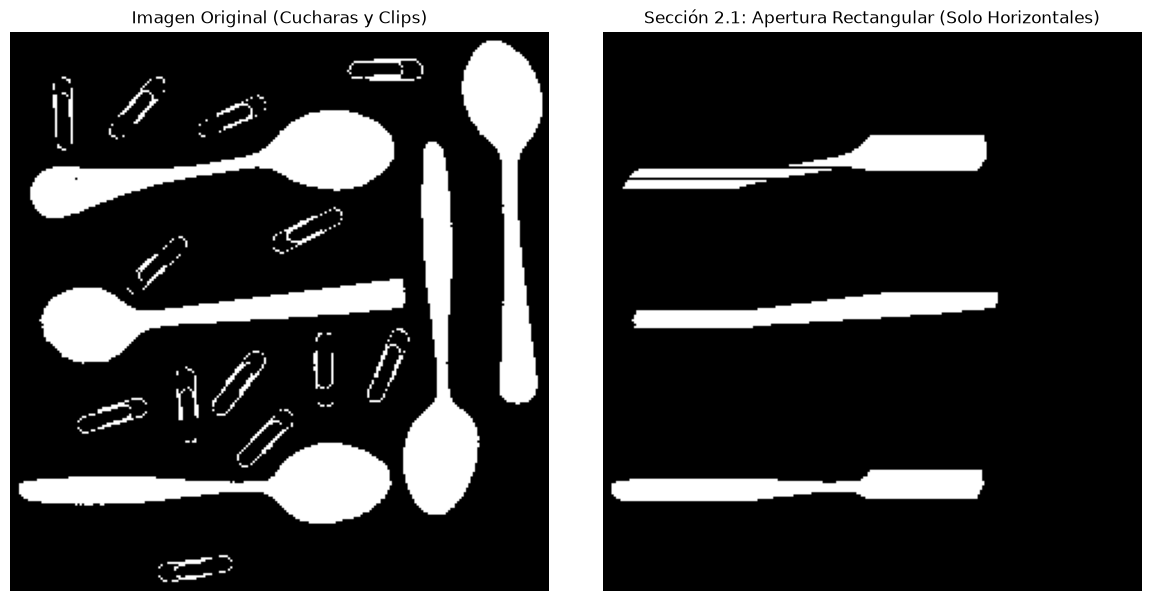

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.morphology import footprint_rectangle, opening

# 1. Leer la imagen binaria 'spoons_binary.png'
img_spoons = io.imread('spoons_binary.png', as_gray=True)

# Asegurarnos de que sea un arreglo booleano (True/False)
binary_spoons = img_spoons > 0.5

# 2. Definir el elemento estructurante rectangular horizontal actualizado (1 fila x 50 columnas)
# Aumentamos el ancho a 50 para asegurarnos de eliminar los clips horizontales
selem_rect = footprint_rectangle((1, 50))

# 3. Aplicar la operación de apertura binaria actualizada
opened_spoons = opening(binary_spoons, selem_rect)

# 4. Visualizar los resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(binary_spoons, cmap='gray')
axes[0].set_title('Imagen Original (Cucharas y Clips)')
axes[0].axis('off')

axes[1].imshow(opened_spoons, cmap='gray')
axes[1].set_title('Sección 2.1: Apertura Rectangular (Solo Horizontales)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Se eliminan todos los clips y las cucharas verticales/diagonales. Sin embargo, las tres cucharas horizontales que sobrevivieron se ven "mordidas", deformadas o más delgadas en sus extremos.

Esto es normal y la guía del laboratorio lo advierte expresamente. Al usar el rectángulo de 50 píxeles de ancho para "borrar" objetos indeseados mediante la operación de apertura, también erosionamos las partes curvas de las cucharas horizontales donde ese rectángulo rígido no cabía (como las cabezas redondas de las cucharas)

## 2.2 RECONSTRUCTION OF THE HORIZONTAL SPOONS

Queremos que esas cucharas deformes vuelvan a tener su forma y grosor original, pero sin revivir los clips ni las otras cucharas que ya borramos. Para lograrlo usaremos una técnica llamada Dilatación Condicional (o reconstrucción geodésica):   

El Marcador (Semilla): Usaremos tu imagen actual (las cucharas mordidas) como punto de partida.La Máscara (Molde): Usaremos la imagen binaria original (la que tiene todo) como límite.El Elemento Estructurante: Usaremos un diamante muy pequeño (diamond(1)).   

El Bucle (While): Haremos crecer nuestra "semilla" dilatándola paso a pasito con el diamante. Al dilatarse, la cuchara se expande. Pero justo después de expandirla, le aplicamos una compuerta lógica AND (np.logical_and) con la imagen original. Esto actúa como una pared: la cuchara puede crecer para recuperar su forma, pero nunca podrá crecer en los píxeles donde la imagen original era negra.   

Repetiremos este ciclo una y otra vez hasta que la semilla se expanda por completo y llene su "molde" original. Cuando la imagen ya no cambia entre un ciclo y el siguiente, el bucle se rompe. 

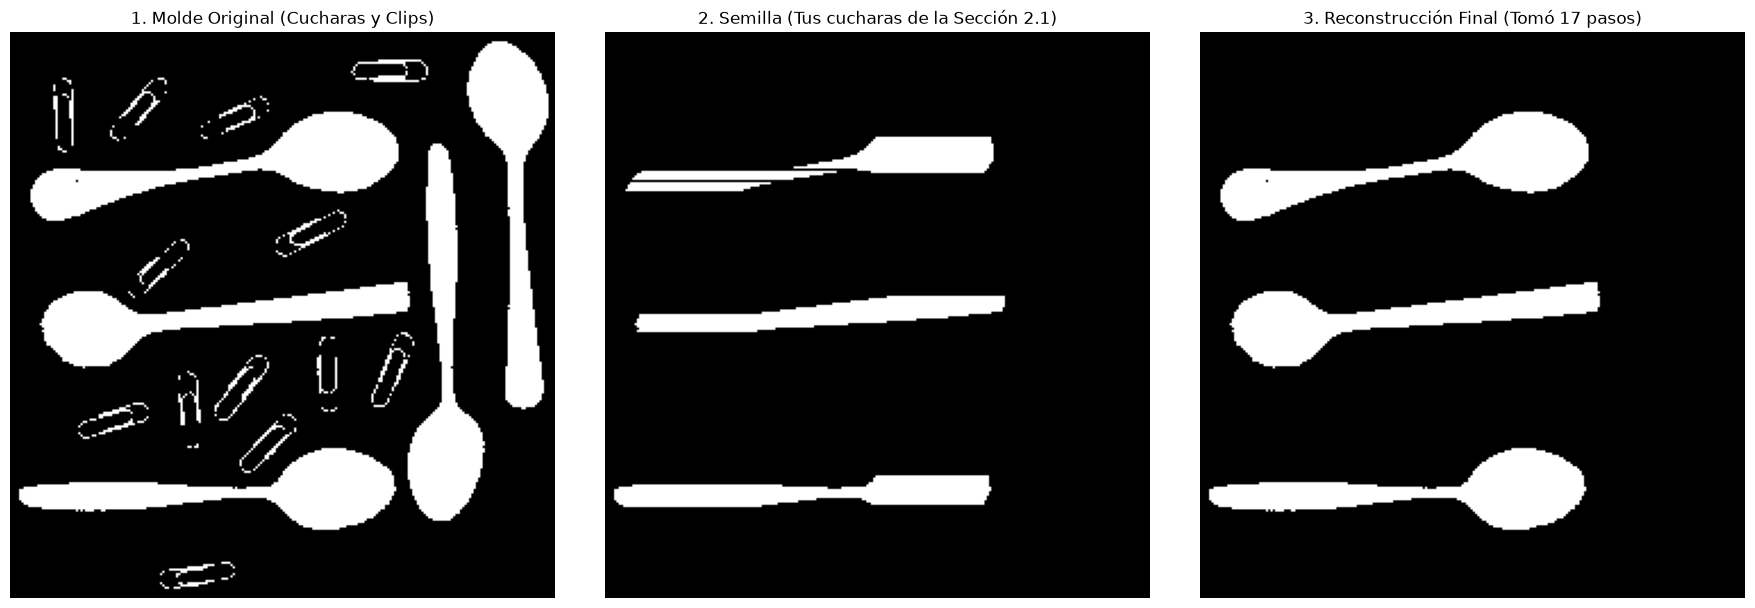

In [3]:
from skimage.morphology import diamond, dilation

# 1. Definir el elemento estructurante: un diamante de tamaño 1
selem_diamond = diamond(1)

# 2. Crear la función solicitada por la guía
def dilate_mask(marker, mask):
    """
    Dilata el marcador un paso y limita su crecimiento al molde original (mask)
    """
    dilated = dilation(marker, selem_diamond)
    return np.logical_and(dilated, mask)

# 3. Proceso de reconstrucción iterativa
current = opened_spoons.copy() # Iniciamos con tus cucharas "mordidas"
iterations = 0

# Bucle infinito que se detendrá solo cuando la imagen deje de cambiar
while True:
    prev = current.copy()
    
    # Hacemos crecer las cucharas respetando los límites originales
    current = dilate_mask(current, binary_spoons)
    iterations += 1
    
    # Condición de parada: si la imagen actual es igual a la anterior, terminamos
    if np.array_equal(current, prev):
        break

reconstructed_spoons = current

# 4. Visualización del proceso completo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(binary_spoons, cmap='gray')
axes[0].set_title('1. Molde Original (Cucharas y Clips)')
axes[0].axis('off')

axes[1].imshow(opened_spoons, cmap='gray')
axes[1].set_title('2. Semilla (Tus cucharas de la Sección 2.1)')
axes[1].axis('off')

axes[2].imshow(reconstructed_spoons, cmap='gray')
axes[2].set_title(f'3. Reconstrucción Final (Tomó {iterations} pasos)')
axes[2].axis('off')

plt.tight_layout()
plt.show()